In [220]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_1sept, JAL3_25aug, JAL3_7sept, JAL3_4sept

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,JAL7_30apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may

In [221]:
experiments_objects = [JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, 
JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, 
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr,
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may]

# including tiny barrier!
# experiments_objects = [JAL3_7sept, JAL3_4sept, 
# JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
# JAL005_8thSept, JAL005_21stSept, 
# JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr,
# JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr, JAL7_30apr,
# JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may]

In [222]:
from behave_analysis.process.session import get_experiment 
from JR_test_scripts.tracking2features import tracking_to_features

import os
import dill as pickle
import numpy as np
import matplotlib.pyplot as plt
import re

In [12]:
# fixed vars
ceph_path = r"Z:\Jasmine_Laurence\Experimental_Data"
winstor_path = r"W:\branco\Laurence"
save_path = r"Z:\Jasmine_Laurence\LDA_overview"
conditions = ['shelter_only','barrier_pre_flip','barrier_post_flip']
all_angles = ['hdir','hsa','h_preflipbar_a','h_postflipbar_a','h_rightbar_a','h_leftbar_a']
all_features = ['shelter','preflip_barrier','postflip_barrier','left_barrier', 'right_barrier', 'arena_bottom', 'arena_top']

For each session:
- plot PA with and without subsampling
- some sort of test for distribution similarity of real and predicted 

In [162]:
settings = ['all_angles_fr','all_angles_fr_excl_prox_15cm','all_angles_subsampled_fr','all_angles_subsampled_fr_excl_prox_15cm']
colorz = plt.cm.jet(np.linspace(0, 1, len(settings)))

# iterate over sessions
for s,sesh in enumerate(experiments_objects):
    # load session deets
    session = get_experiment(sesh)
    base_path = ceph_path
    if os.path.exists(os.path.join(winstor_path,session.processed_path)):
        base_path = winstor_path
    fig, axs = plt.subplots(1,len(conditions))
    plt.rcParams['figure.figsize'] = [15, 5]
    line_object = []
    for idx,c in enumerate(conditions):
        for idx_s, set in enumerate(settings):
            coef_path = os.path.join(base_path,
                                        session.processed_path,
                                        'models',
                                        'LDA',
                                        set,
                                        r'good\experimental_conditions\all',
                                        c,
                                        str('good_' + c + '_LDA_pa.pkl'))
            with open(coef_path, "rb") as dill_file:
                coef = pickle.load(dill_file)
            angles = [key for key, val in coef.items() if np.logical_and(not re.search("time", key),not re.search("randP", key))]
            pa = [val for key, val in coef.items() if np.logical_and(not re.search("time", key),not re.search("randP", key))]
            line, = axs[idx].plot(angles,pa, color = colorz[idx_s])
            if idx == 0: line_object.append(line)
            x = [len(angles)]
            pa = [val for key, val in coef.items() if np.logical_and(not re.search("time", key),re.search("randP", key))]
            violin = axs[idx].violinplot(dataset = pa,positions = x,showextrema = False)
            for v in violin['bodies']:
                v.set_alpha(.5)
                v.set_facecolor(colorz[idx_s])
            axs[idx].set_ylim([0,1])
            axs[idx].set_title(c)
            axs[idx].set_xticklabels(angles,rotation = 45, ha="right")
    axs[idx].legend(line_object,settings,
                    loc='center left', 
                    bbox_to_anchor=(1.5, .5),
                    columnspacing=1.0, labelspacing=0.2,
                    handletextpad=0.5, handlelength=1.5)
    axs[0].set_ylabel('prediction accuracy')

    # save image to folder
    name = sesh.nick_name + '_' + sesh.experiment_date
    save_path = r"Z:\Jasmine_Laurence\LDA_overview"
    plt.savefig(save_path+'/'+name+'.png', bbox_inches='tight')
    plt.close()

C:\Users\jreggiani\AppData\Local\Temp\ipykernel_8524\1737501978.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[idx].set_xticklabels(angles,rotation = 45, ha="right")


Across sessions:
- prediction accuracy for each barrier in each condition 
- look at spatial efficiency in escape and prediction accuracy
- look at prediction accuracy in first vs second half

In [223]:
# fixed vars
settings = 'all_angles_fr'
# 'all_angles_fr','all_angles_fr_excl_prox_15cm','all_angles_subsampled_fr','all_angles_subsampled_fr_excl_prox_15cm'

In [224]:
# pulling out prediction accuracy for all sessions for a certain set of settings

sessy = {}
all_names = []
pa = {}
avg_pa = {}
for a in all_angles:
    pa[a] = np.empty((len(experiments_objects),len(conditions)))
for a in all_features:
    avg_pa[a] = np.empty((len(experiments_objects), len(conditions)))

for s,sesh in enumerate(experiments_objects):
    # find session
    session = get_experiment(sesh)
    base_path = ceph_path
    if os.path.exists(os.path.join(winstor_path,session.processed_path)):
        base_path = winstor_path
    
    # load tracking
    track_path = os.path.join(base_path,session.processed_path,r"fully_processed_tracking_data.pickle")
    with open(track_path, "rb") as dill_file:
        tracking_data = pickle.load(dill_file)
    features = tracking_to_features(tracking_data)

    # load prediction accuracy
    coef = {}
    for idx,c in enumerate(conditions):
        coef_path = os.path.join(base_path,
                                 session.processed_path,
                                 'models',
                                 'LDA',
                                 settings,
                                 r'good\experimental_conditions\all',
                                 c,
                                 str('good_' + c + '_LDA_pa.pkl'))
        if not os.path.exists(coef_path):
            print("path still doesn't exist: " + coef_path)
        with open(coef_path, "rb") as dill_file:
            coef[c] = pickle.load(dill_file)
        point_grid = []
        for a in coef[c].keys():
            if a in all_angles:
                pa[a][s,idx] = coef[c][a]
            if 'rand' in a:
                point_grid.append(coef[c][a])
        b = [b[0] for b in tracking_data['barrier_loc']]
        if b[0] > b[1]: # preflip barrier on the right
            pa['h_rightbar_a'][s,idx] = coef[c]['h_preflipbar_a']
            pa['h_leftbar_a'][s,idx] = coef[c]['h_postflipbar_a']
        else:
            pa['h_rightbar_a'][s,idx] = coef[c]['h_postflipbar_a']
            pa['h_leftbar_a'][s,idx] = coef[c]['h_preflipbar_a']
        
        # avrage random point pred.acc. for shelter and barrier
        point_grid = np.array(point_grid)
        for a in features.keys():
            avg_pa[a][s,idx] = np.mean(point_grid[features[a]])

    name = sesh.nick_name + '_' + sesh.experiment_date
    all_names.append(name)
    sessy[name] = coef
    # print(name)

C:\Users\jreggiani\AppData\Local\Temp\ipykernel_8524\3825486462.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")


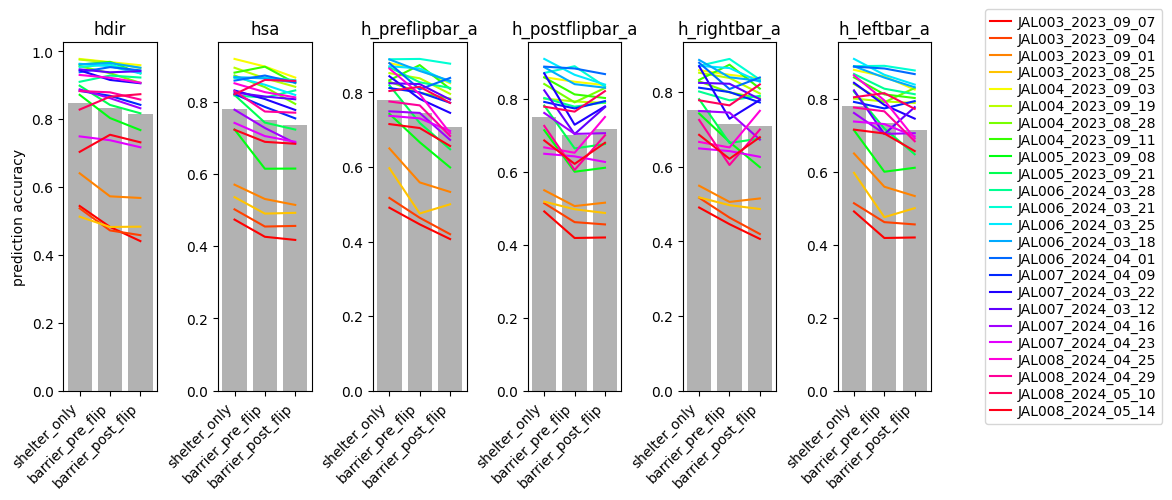

In [225]:
'''Plot the predicton accuracy for all sessions for the standard angles'''
fig, axs = plt.subplots(1,len(all_angles))
plt.rcParams['figure.figsize'] = [10, 5]
for idx, a in enumerate(all_angles):
    axs[idx].set_prop_cycle(plt.cycler('color', plt.cm.hsv(np.linspace(0, 1, len(pa[a])))))
    axs[idx].plot(conditions,pa[a].T)
    axs[idx].bar(conditions,np.mean(pa[a],axis=0),color = 'k',alpha = .3)
    axs[idx].set_title(a)
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
axs[idx].legend(all_names,
                loc='center left', 
                bbox_to_anchor=(1.5, .5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
axs[0].set_ylabel('prediction accuracy')
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_allsesh_'+settings+'.png'))

C:\Users\jreggiani\AppData\Local\Temp\ipykernel_8524\4291408355.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")


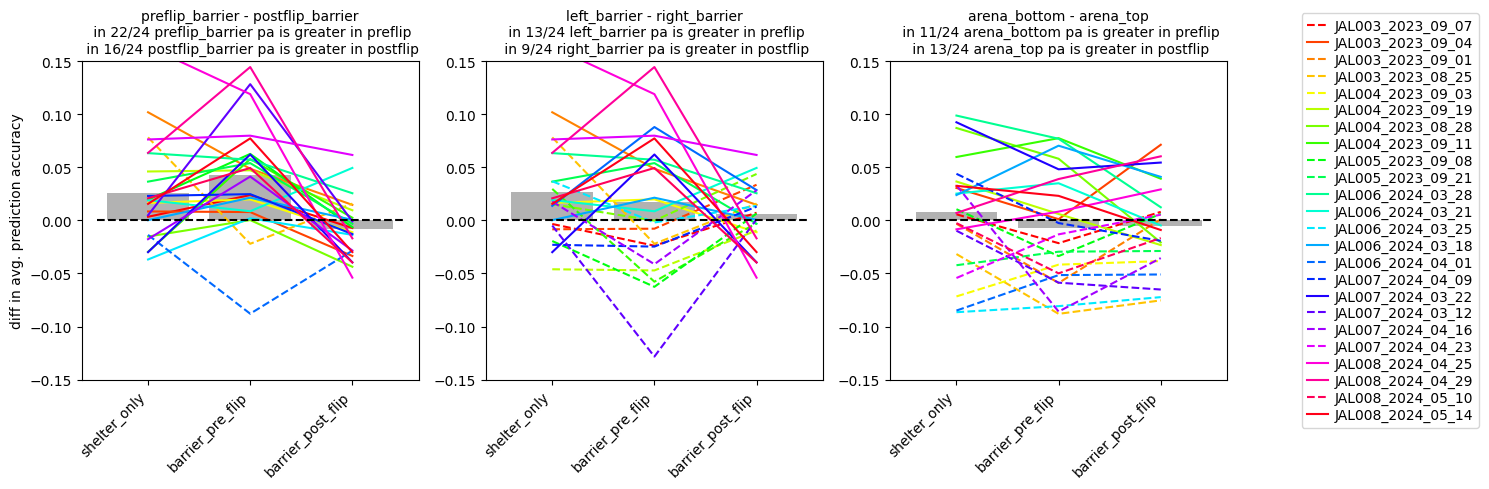

In [226]:
''' Plot the difference in pa (averaged over an area) for two goals'''
combos = [['preflip_barrier','postflip_barrier'],['left_barrier', 'right_barrier'], ['arena_bottom', 'arena_top']]

plt.rcParams['figure.figsize'] = [15, 5]
fig, axs = plt.subplots(1,len(combos))

for idx,c in enumerate(combos):
    diff = avg_pa[c[0]] - avg_pa[c[1]]
    axs[idx].bar(conditions,np.nanmean(diff,axis=0),color = 'k',alpha = .3)
    axs[idx].set_prop_cycle(plt.cycler('color', plt.cm.hsv(np.linspace(0, 1, len(avg_pa[c[0]])))))
    for p in diff:
        if p[1] > 0: # p[2]:
            axs[idx].plot(conditions,p)
        else:
            axs[idx].plot(conditions,p,'--')
    axs[idx].plot([-.5,2.5],[0,0],'--k')
    axs[idx].set_title(c[0] + ' - ' + c[1]  +  
                       '\n in ' + str(np.sum(diff[:,1]>0)) + '/' + str(len(avg_pa[c[0]])) + ' ' + c[0] + ' pa is greater in preflip' +
                       '\n in ' + str(np.sum(diff[:,2]<0)) + '/' + str(len(avg_pa[c[0]])) + ' ' + c[1] + ' pa is greater in postflip',
                       fontsize = 10)
    
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
    axs[idx].set_ylim([-.15,.15])
axs[0].set_ylabel('diff in avg. prediction accuracy')
axs[idx].legend(all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
plt.tight_layout()
plt.savefig(save_path+'/'+str('AVGpa_diff_allsesh_'+settings+'.png'))

C:\Users\jreggiani\AppData\Local\Temp\ipykernel_8524\3729111991.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")


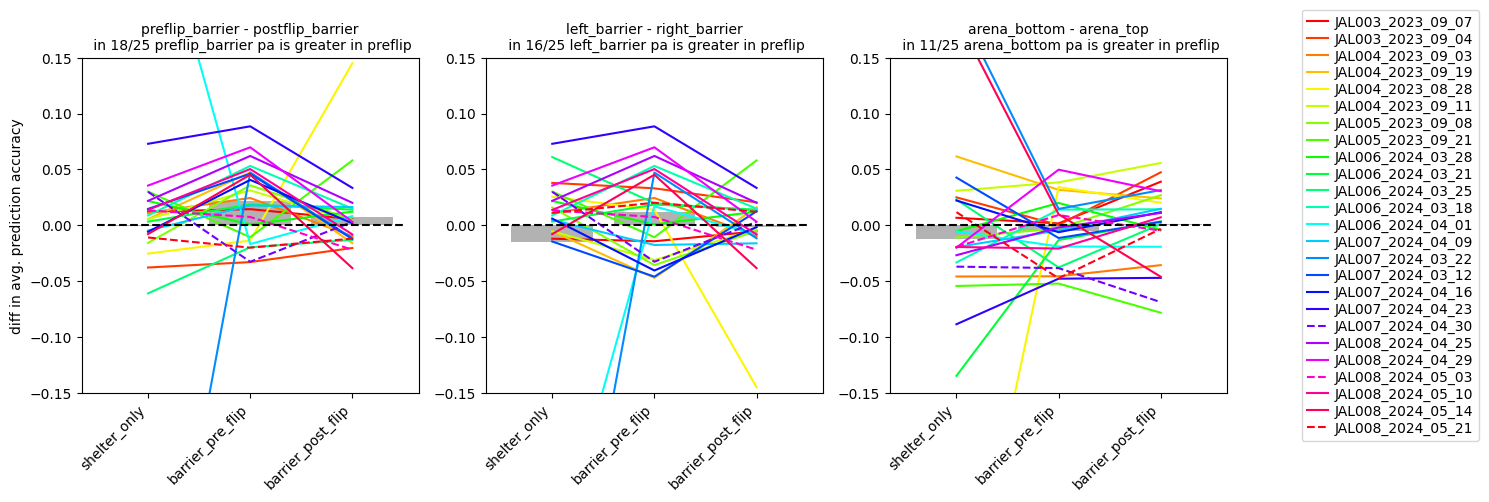

In [149]:
''' Plot the difference in pa (averaged over an area) for two goals,
but dash the ones that have tinny barrier'''
combos = [['preflip_barrier','postflip_barrier'],['left_barrier', 'right_barrier'], ['arena_bottom', 'arena_top']]

plt.rcParams['figure.figsize'] = [15, 5]
fig, axs = plt.subplots(1,len(combos))

for idx,c in enumerate(combos):
    diff = avg_pa[c[0]] - avg_pa[c[1]]
    axs[idx].bar(conditions,np.nanmean(diff,axis=0),color = 'k',alpha = .3)
    axs[idx].set_prop_cycle(plt.cycler('color', plt.cm.hsv(np.linspace(0, 1, len(avg_pa[c[0]])))))
    for s, p in enumerate(diff):
        if all_names[s] in ['JAL007_2024_04_30','JAL008_2024_05_03','JAL008_2024_05_21']:
            axs[idx].plot(conditions,p,'--')
        else:
            axs[idx].plot(conditions,p)
    axs[idx].plot([-.5,2.5],[0,0],'--k')
    axs[idx].set_title(c[0] + ' - ' + c[1]  +  
                       '\n in ' + str(np.sum(diff[:,1]>0)) + '/' + str(len(avg_pa[c[0]])) + ' ' + c[0] + ' pa is greater in preflip' +
                       '\n in ' + str(np.sum(diff[:,2]<0)) + '/' + str(len(avg_pa[c[0]])) + ' ' + c[1] + ' pa is greater in postflip',
                       fontsize = 10)
    
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
    axs[idx].set_ylim([-.15,.15])
axs[0].set_ylabel('diff in avg. prediction accuracy')
axs[idx].legend(all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
plt.tight_layout()
plt.savefig(save_path+'/'+str('AVGpa_diff_allsesh_'+settings+'_excl_tinny.png'))

C:\Users\jreggiani\AppData\Local\Temp\ipykernel_8524\2361249994.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")


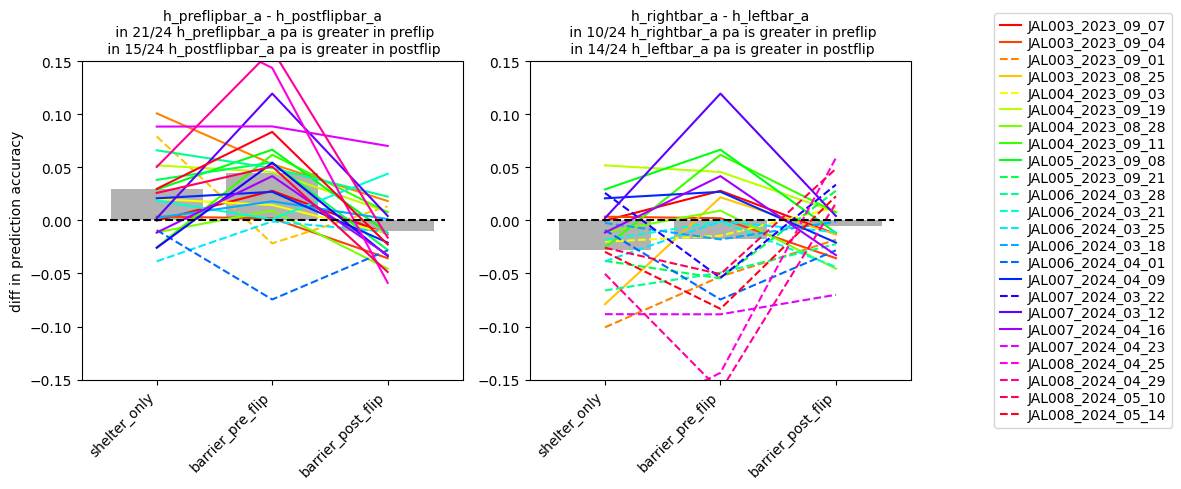

In [227]:
''' Plot the difference in pa for two goals'''
combos = [['h_preflipbar_a','h_postflipbar_a'],['h_rightbar_a','h_leftbar_a']]

plt.rcParams['figure.figsize'] = [12, 5]
fig, axs = plt.subplots(1,len(combos))

for idx,c in enumerate(combos):
    diff = pa[c[0]] - pa[c[1]]
    axs[idx].bar(conditions,np.nanmean(diff,axis=0),color = 'k',alpha = .3)
    axs[idx].set_prop_cycle(plt.cycler('color', plt.cm.hsv(np.linspace(0, 1, len(pa[c[0]])))))
    for p in diff:
        if p[1] > 0: #p[2]:
            axs[idx].plot(conditions,p)
        else:
            axs[idx].plot(conditions,p,'--')
    axs[idx].plot([-.5,2.5],[0,0],'--k')
    axs[idx].set_title(c[0] + ' - ' + c[1]  +  
                       '\n in ' + str(np.sum(diff[:,1]>0)) + '/' + str(len(pa[c[0]])) + ' ' + c[0] + ' pa is greater in preflip' +
                       '\n in ' + str(np.sum(diff[:,2]<0)) + '/' + str(len(pa[c[0]])) + ' ' + c[1] + ' pa is greater in postflip',
                       fontsize = 10)
    # axs[idx].set_title(c[0] + ' - ' + c[1]  +  
    #                    '\n in ' + str(np.sum(diff[:,1]>diff[:,2])) + '/' + str(len(pa[c[0]])) + ' ' + c[0] + ' pa is greater in preflip',
    #                    fontsize = 10)
    
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
    axs[idx].set_ylim([-.15,.15])
axs[0].set_ylabel('diff in prediction accuracy')
axs[idx].legend(all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff_allsesh_'+settings+'.png'))

Compare difference in prediction accuracy over time

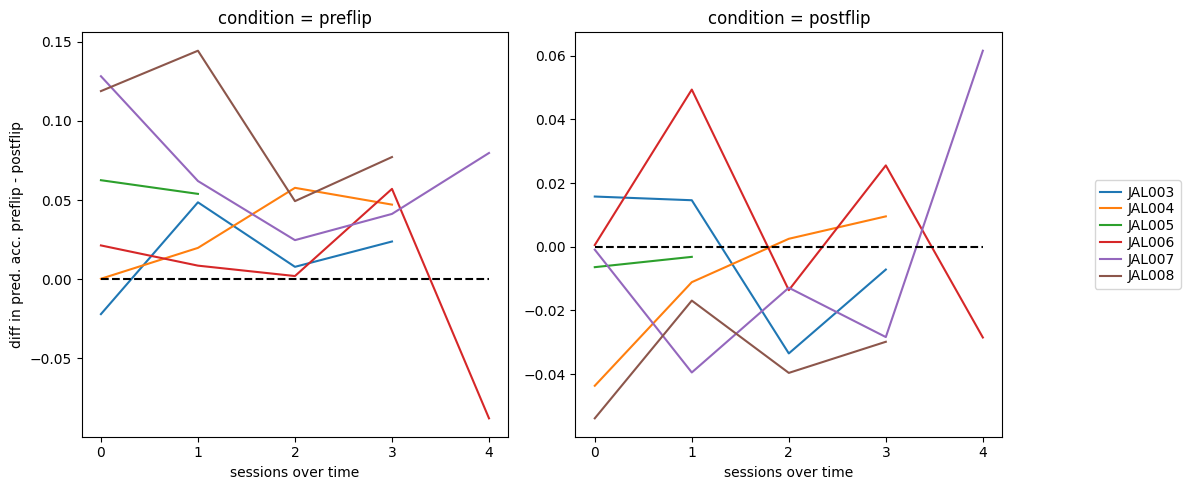

In [246]:
'''Find for each mouse the sessions in order and plot the prediction accuracy'''
mouse = ['JAL003','JAL004','JAL005','JAL006','JAL007','JAL008']
diff = pa['h_preflipbar_a'] - pa['h_postflipbar_a']
diff = avg_pa['preflip_barrier'] - avg_pa['postflip_barrier']

plt.rcParams['figure.figsize'] = [12, 5]
fig, axs = plt.subplots(1,2)

from datetime import datetime
def extract_date(t):
    date_str = t[0].split('_')[1:]
    date_str = '_'.join(date_str)
    return datetime.strptime(date_str, '%Y_%m_%d')

for m in mouse:
    this_m = [(c,d) for c,d in zip(all_names,diff[:,1]) if m in c]
    sorted_m = sorted(this_m, key=extract_date)
    values = [t[1] for t in sorted_m]
    axs[0].plot(values)
    this_m = [(c,d) for c,d in zip(all_names,diff[:,2]) if m in c]
    sorted_m = sorted(this_m, key=extract_date)
    values = [t[1] for t in sorted_m]
    axs[1].plot(values)

axs[0].set_ylabel('diff in pred. acc. preflip - postflip')
axs[0].set_title('condition = preflip')
axs[1].set_title('condition = postflip')
axs[1].legend(mouse,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
for i in [0,1]: 
    axs[i].plot([0,4],[0,0],'--k')
    axs[i].set_xlabel('sessions over time')
    axs[i].set_xticks(np.arange(0,5,1))

plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff_allsesh_'+settings+'_overtime.png'))

In [248]:
m

'JAL008'

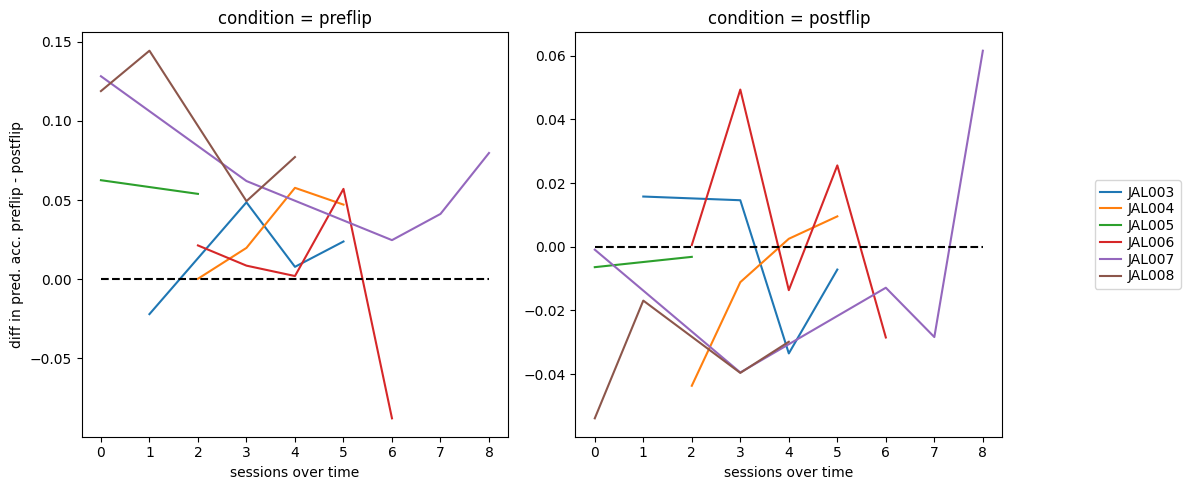

In [249]:
'''Find for each mouse the sessions in order and plot the prediction accuracy,
labeled by which barrier sessions this is'''
mouse = ['JAL003','JAL004','JAL005','JAL006','JAL007','JAL008']
sesh = [[1,3,4,5],[2,3,4,5],[0,2],[2,3,4,5,6],[0,3,6,7,8],[0,1,3,4]]
diff = pa['h_preflipbar_a'] - pa['h_postflipbar_a']
diff = avg_pa['preflip_barrier'] - avg_pa['postflip_barrier']

plt.rcParams['figure.figsize'] = [12, 5]
fig, axs = plt.subplots(1,2)

from datetime import datetime
def extract_date(t):
    date_str = t[0].split('_')[1:]
    date_str = '_'.join(date_str)
    return datetime.strptime(date_str, '%Y_%m_%d')

for m,s in zip(mouse,sesh):
    this_m = [(c,d) for c,d in zip(all_names,diff[:,1]) if m in c]
    sorted_m = sorted(this_m, key=extract_date)
    values = [t[1] for t in sorted_m]
    axs[0].plot(s,values)
    this_m = [(c,d) for c,d in zip(all_names,diff[:,2]) if m in c]
    sorted_m = sorted(this_m, key=extract_date)
    values = [t[1] for t in sorted_m]
    axs[1].plot(s,values)

axs[0].set_ylabel('diff in pred. acc. preflip - postflip')
axs[0].set_title('condition = preflip')
axs[1].set_title('condition = postflip')
axs[1].legend(mouse,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
for i in [0,1]: 
    axs[i].plot([0,8],[0,0],'--k')
    axs[i].set_xlabel('sessions over time')
    axs[i].set_xticks(np.arange(0,9,1))

plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff_allsesh_'+settings+'_overtime.png'))

Compare prediction accuracy to spatial efficiency

In [211]:
'''compare to spatial efficiency'''
se = {}
for c in conditions:
    se[c] = np.empty((len(experiments_objects)))

for s,sesh in enumerate(experiments_objects):
    # find session
    session = get_experiment(sesh)
    base_path = ceph_path
    if os.path.exists(os.path.join(winstor_path,session.processed_path)):
        base_path = winstor_path
    
    # load tracking
    track_path = os.path.join(base_path,session.processed_path,'escapes',r"escapes_obj.pkl")
    with open(track_path, "rb") as dill_file:
        esc = pickle.load(dill_file)
    for c in conditions:
        se[c][s] = np.mean([x for x, y in zip(esc.spatial_efficiency,esc.escape_condition) if y[0] == c])

c:\Users\jreggiani\Miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jreggiani\Miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


C:\Users\jreggiani\AppData\Local\Temp\ipykernel_8524\634799438.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  line = axs[2].scatter(s,p,s=5,c=cz)


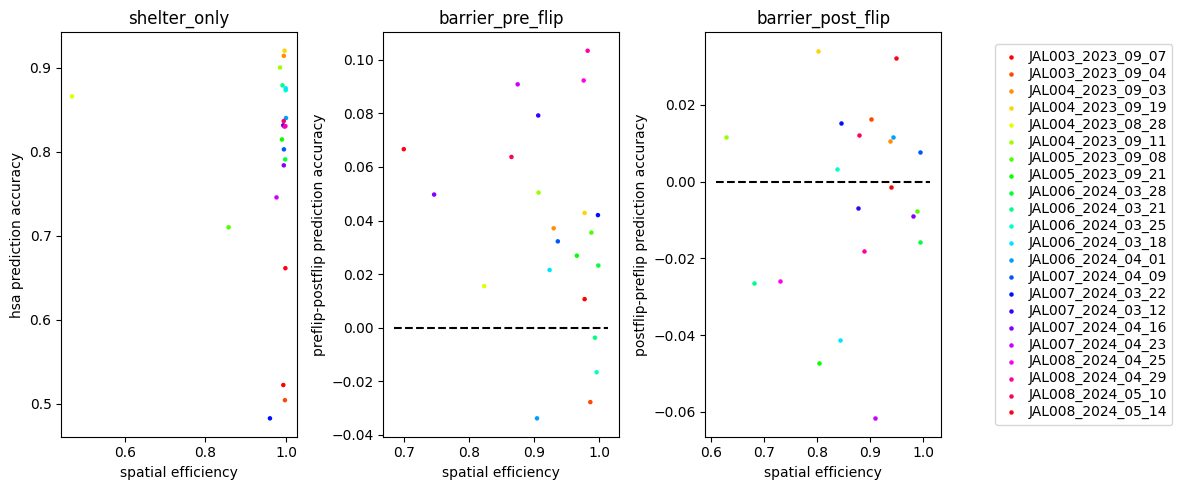

In [219]:
fig, axs = plt.subplots(1,3)
colorz = plt.cm.hsv(np.linspace(0, 1, len(se['shelter_only'])))
# shelter only
axs[0].scatter(se['shelter_only'],pa['hsa'][:,0],s=5,c=colorz)
axs[0].set_xlabel('spatial efficiency')
axs[0].set_ylabel('hsa prediction accuracy')
axs[0].set_title('shelter_only')

# barrier_pre_flip
axs[1].scatter(se['barrier_pre_flip'],pa['h_preflipbar_a'][:,1]-pa['h_postflipbar_a'][:,1],s=5,c=colorz)
axs[1].plot(axs[1].get_xlim(),[0,0],'--k')
axs[1].set_xlabel('spatial efficiency')
axs[1].set_ylabel('preflip-postflip prediction accuracy')
axs[1].set_title('barrier_pre_flip')

# barrier_post_flip
line_object = []
for s,p,cz in zip(se['barrier_post_flip'],pa['h_postflipbar_a'][:,2]-pa['h_preflipbar_a'][:,2],colorz):
    line = axs[2].scatter(s,p,s=5,c=cz)
    line_object.append(line)
axs[2].plot(axs[2].get_xlim(),[0,0],'--k')
axs[2].set_xlabel('spatial efficiency')
axs[2].set_ylabel('postflip-preflip prediction accuracy')
axs[2].set_title('barrier_post_flip')

axs[2].legend(line_object, all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)


plt.tight_layout()
plt.savefig(save_path+'/'+str('spatial_efficiency_pa_diff_allsesh_'+settings+'.png'))

Compare preidction accuracy in first vs last 20 mins

In [183]:
# pulling out prediction accuracy for all sessions for a certain set of settings
settings = 'all_angles_fr' # has only be computed in the non subsampled one
time_cond = ['first_half','second_half']
conditions_h = conditions #['barrier_pre_flip','barrier_post_flip']

sessy = {}
all_names = []
pa = {}
avg_pa = {}
for a in all_angles:
    pa[a] = np.empty((len(experiments_objects),len(conditions_h),2))
for a in all_features:
    avg_pa[a] = np.empty((len(experiments_objects), len(conditions_h),2))

for s,sesh in enumerate(experiments_objects):
    # find session
    session = get_experiment(sesh)
    base_path = ceph_path
    if os.path.exists(os.path.join(winstor_path,session.processed_path)):
        base_path = winstor_path
    
    # load tracking
    track_path = os.path.join(base_path,session.processed_path,r"fully_processed_tracking_data.pickle")
    with open(track_path, "rb") as dill_file:
        tracking_data = pickle.load(dill_file)
    features = tracking_to_features(tracking_data)

    # load prediction accuracy
    coef = {}
    for h_idx,h in enumerate(time_cond):
        for idx,c in enumerate(conditions_h):
            coef_path = os.path.join(base_path,
                                    session.processed_path,
                                    'models',
                                    'LDA',
                                    settings,
                                    'good',
                                    h,
                                    'all',
                                    c,
                                    str('good_' + c + '_LDA_pa.pkl'))
            if not os.path.exists(coef_path):
                print("path still doesn't exist: " + coef_path)
            with open(coef_path, "rb") as dill_file:
                coef[c] = pickle.load(dill_file)
            point_grid = []
            for a in coef[c].keys():
                if a in all_angles:
                    pa[a][s,idx,h_idx] = coef[c][a]
                if 'rand' in a:
                    point_grid.append(coef[c][a])
            b = [b[0] for b in tracking_data['barrier_loc']]
            if b[0] > b[1]: # preflip barrier on the right
                pa['h_rightbar_a'][s,idx,h_idx] = coef[c]['h_preflipbar_a']
                pa['h_leftbar_a'][s,idx,h_idx] = coef[c]['h_postflipbar_a']
            else:
                pa['h_rightbar_a'][s,idx,h_idx] = coef[c]['h_postflipbar_a']
                pa['h_leftbar_a'][s,idx,h_idx] = coef[c]['h_preflipbar_a']
            
            # avrage random point pred.acc. for shelter and barrier
            point_grid = np.array(point_grid)
            for a in features.keys():
                avg_pa[a][s,idx,h_idx] = np.mean(point_grid[features[a]])

    name = sesh.nick_name + '_' + sesh.experiment_date
    all_names.append(name)
    sessy[name] = coef

C:\Users\jreggiani\AppData\Local\Temp\ipykernel_8524\956244867.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[idx_c,idx].set_xticklabels(time_cond,rotation = 45, ha="right")


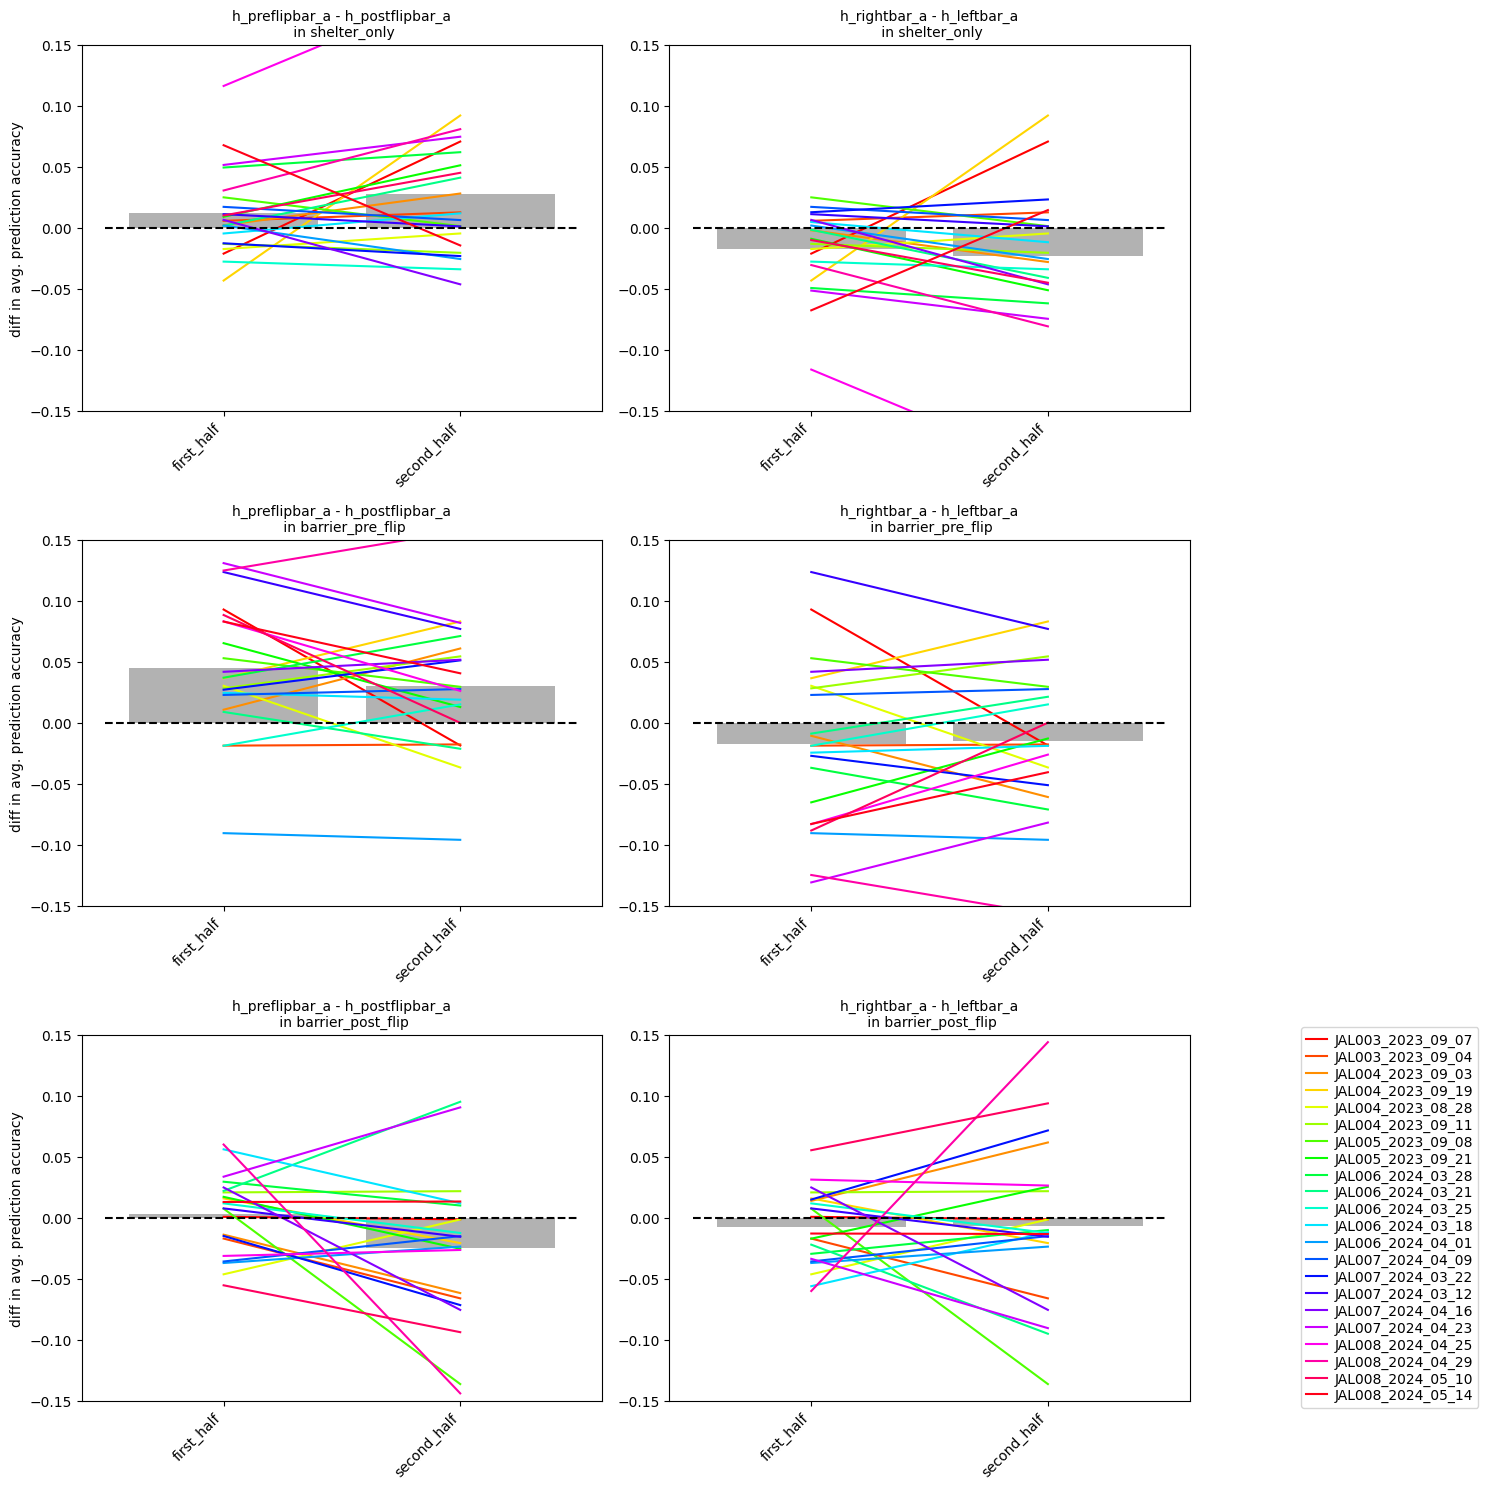

In [185]:
''' Plot the difference in pa for two goals'''
combos = [['h_preflipbar_a','h_postflipbar_a'],['h_rightbar_a','h_leftbar_a']]

plt.rcParams['figure.figsize'] = [15, 5*len(conditions_h)]
fig, axs = plt.subplots(len(conditions_h),len(combos))

for idx,c in enumerate(combos):
    for idx_c,cd in enumerate(conditions_h):
        diff = pa[c[0]][:,idx_c,:] - pa[c[1]][:,idx_c,:]
        axs[idx_c,idx].bar(time_cond,np.nanmean(diff,axis=0),color = 'k',alpha = .3)
        axs[idx_c,idx].set_prop_cycle(plt.cycler('color', plt.cm.hsv(np.linspace(0, 1, len(pa[c[0]])))))
        for p in diff:
            axs[idx_c,idx].plot(time_cond,p)
        axs[idx_c,idx].set_title(c[0] + ' - ' + c[1]  +  
                        '\n in ' + cd,
                        fontsize = 10)
        axs[idx_c,idx].plot([-.5,1.5],[0,0],'--k')
        
        axs[idx_c,idx].set_xticklabels(time_cond,rotation = 45, ha="right")
        axs[idx_c,idx].set_ylim([-.15,.15])
        axs[idx_c,0].set_ylabel('diff in avg. prediction accuracy')
axs[idx_c,idx].legend(all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff_allsesh_'+settings+'_time_cond_allcond.png'))

C:\Users\jreggiani\AppData\Local\Temp\ipykernel_8524\2566318269.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[idx_c,idx].set_xticklabels(time_cond,rotation = 45, ha="right")


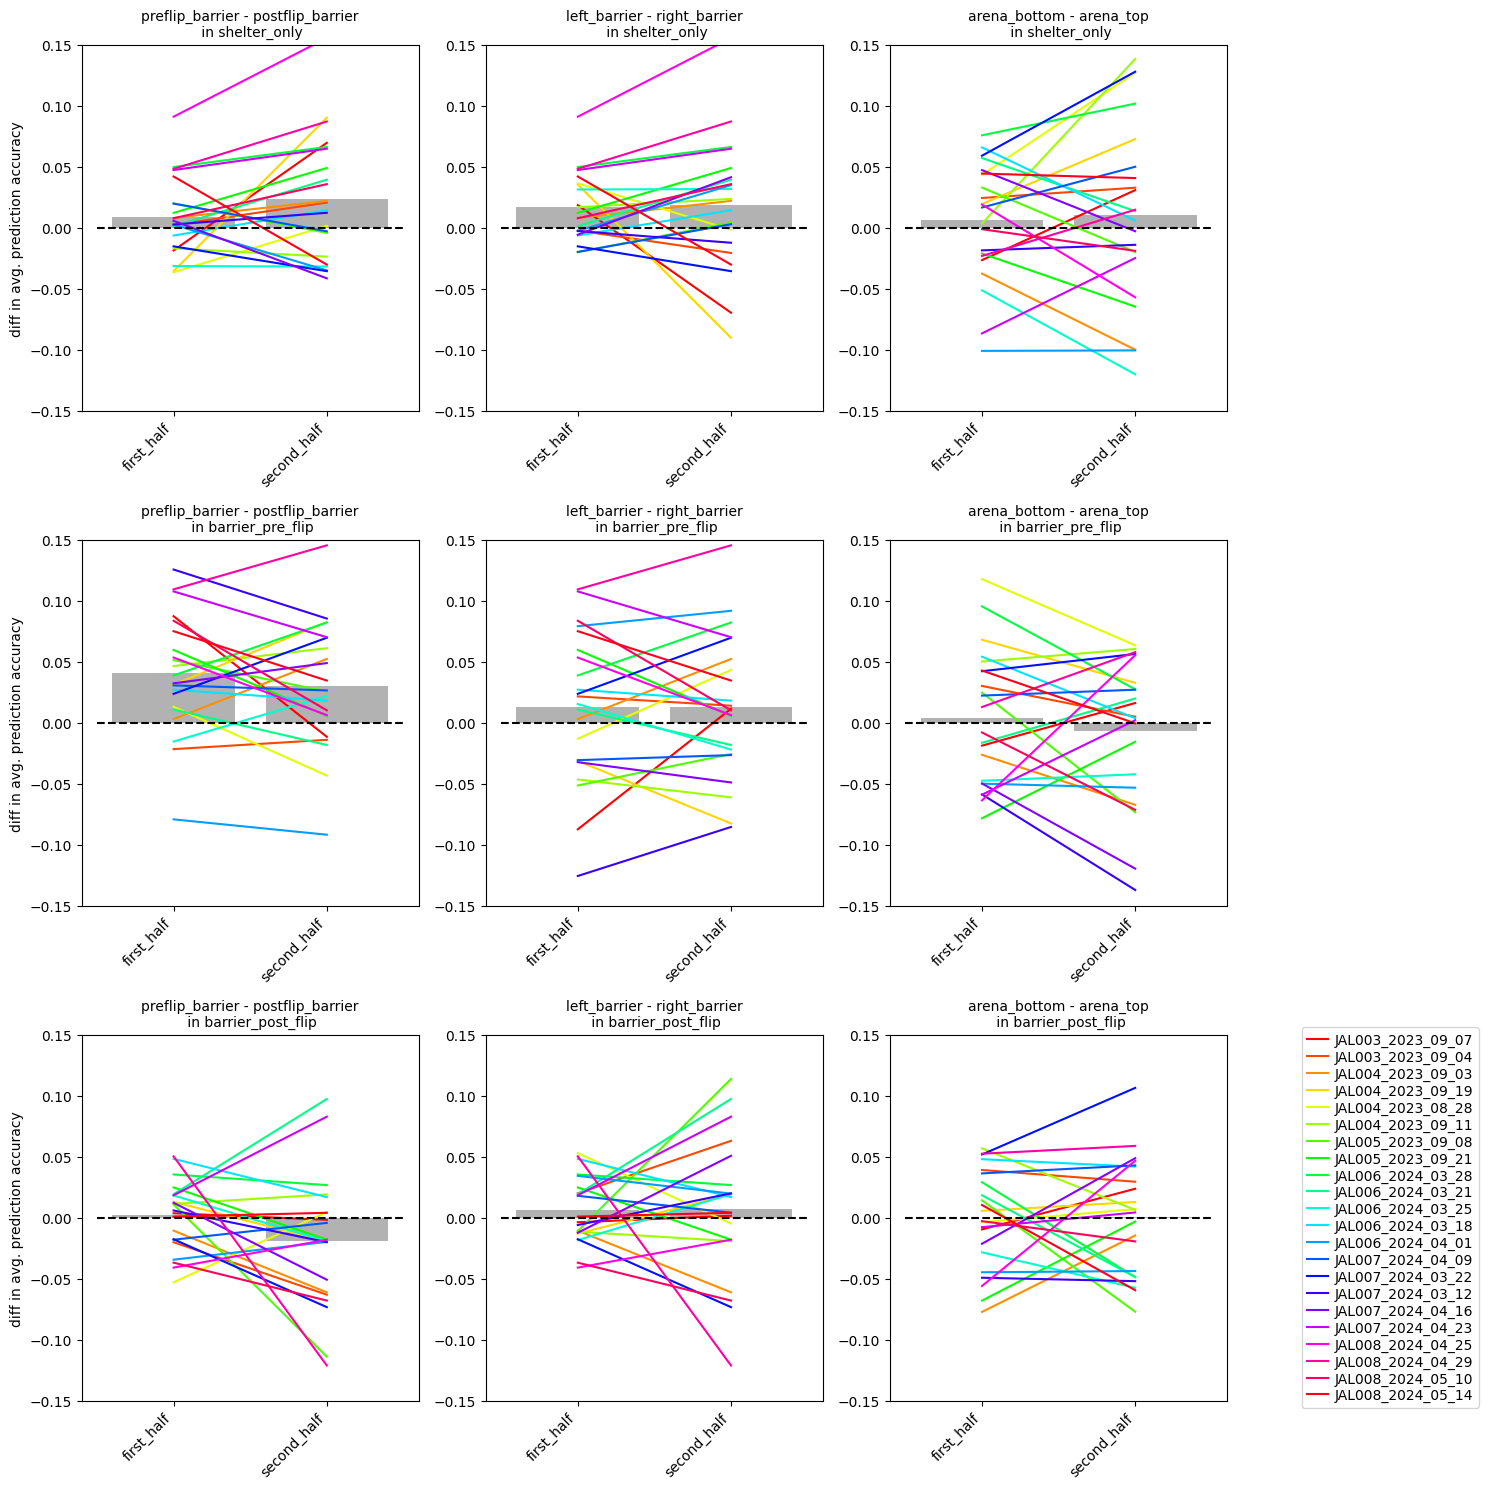

In [187]:
''' Plot the difference in pa (averaged over an area) for two goals'''
combos = [['preflip_barrier','postflip_barrier'],['left_barrier', 'right_barrier'], ['arena_bottom', 'arena_top']]

plt.rcParams['figure.figsize'] = [15, 5*len(conditions_h)]
fig, axs = plt.subplots(len(conditions_h),len(combos))

for idx,c in enumerate(combos):
    for idx_c,cd in enumerate(conditions_h):
        diff = avg_pa[c[0]][:,idx_c,:] - avg_pa[c[1]][:,idx_c,:]
        axs[idx_c,idx].bar(time_cond,np.nanmean(diff,axis=0),color = 'k',alpha = .3)
        axs[idx_c,idx].set_prop_cycle(plt.cycler('color', plt.cm.hsv(np.linspace(0, 1, len(avg_pa[c[0]])))))
        for p in diff:
            axs[idx_c,idx].plot(time_cond,p)
        axs[idx_c,idx].set_title(c[0] + ' - ' + c[1]  +  
                        '\n in ' + cd,
                        fontsize = 10)
        axs[idx_c,idx].plot([-.5,1.5],[0,0],'--k')
        
        axs[idx_c,idx].set_xticklabels(time_cond,rotation = 45, ha="right")
        axs[idx_c,idx].set_ylim([-.15,.15])
        axs[idx_c,0].set_ylabel('diff in avg. prediction accuracy')
axs[idx_c,idx].legend(all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
plt.tight_layout()
plt.savefig(save_path+'/'+str('AVGpa_diff_allsesh_'+settings+'_time_cond_allcond.png'))